**Header**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
print(f"✓ TensorFlow: {tf.__version__}")
print(f"✓ GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

BASE    = '/content/drive/MyDrive/churn_project/'
PROC    = BASE + 'data/processed/'
RESULTS = BASE + 'results/'

Mounted at /content/drive
✓ TensorFlow: 2.19.0
✓ GPU available: True


**Load preprocessed data:**

In [2]:
with open(PROC + 'smoted_data.pkl', 'rb') as f:
    smoted = pickle.load(f)

datasets = ['Insurance', 'ISP', 'Telecom']

for name in datasets:
    print(f"{name:12} → train: {smoted[name]['X_train'].shape}  "
          f"test: {smoted[name]['X_test'].shape}")

print("\n✓ Data loaded")

Insurance    → train: (47904, 16)  test: (6782, 16)
ISP          → train: (64080, 10)  test: (14455, 10)
Telecom      → train: (4560, 19)  test: (667, 19)

✓ Data loaded


**Reshape data for CNN input:**

In [3]:
# CNN expects 3D input: (samples, timesteps, features)
# We reshape tabular data → (samples, n_features, 1)

cnn_data = {}

for name in datasets:
    X_train = smoted[name]['X_train'].values
    X_test  = smoted[name]['X_test'].values
    y_train = smoted[name]['y_train'].values
    y_test  = smoted[name]['y_test'].values

    # Reshape to 3D
    X_train_3d = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    X_test_3d  = X_test.reshape(X_test.shape[0],  X_test.shape[1],  1)

    cnn_data[name] = {
        'X_train' : X_train_3d,
        'X_test'  : X_test_3d,
        'y_train' : y_train,
        'y_test'  : y_test,
        'n_features': X_train.shape[1]
    }

    print(f"{name:12} → X_train_3d: {X_train_3d.shape}  "
          f"X_test_3d: {X_test_3d.shape}")

print("\n✓ Data reshaped for CNN input")

Insurance    → X_train_3d: (47904, 16, 1)  X_test_3d: (6782, 16, 1)
ISP          → X_train_3d: (64080, 10, 1)  X_test_3d: (14455, 10, 1)
Telecom      → X_train_3d: (4560, 19, 1)  X_test_3d: (667, 19, 1)

✓ Data reshaped for CNN input


**Build LFE-CNN(Lightweight Feature Extractor)**

In [4]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv1D, MaxPooling1D,
                                      Flatten, Dense, Dropout,
                                      BatchNormalization)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

def build_LFE_CNN(n_features):
    """
    Lightweight Feature Extractor CNN — paper's simpler architecture.
    Fewer layers, faster to train, acts as lightweight branch of ensemble.
    """
    inputs = Input(shape=(n_features, 1))

    # Block 1
    x = Conv1D(filters=64, kernel_size=3,
               activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2, padding='same')(x)
    x = Dropout(0.2)(x)

    # Block 2
    x = Conv1D(filters=32, kernel_size=3,
               activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2, padding='same')(x)
    x = Dropout(0.2)(x)

    # Classifier head
    x = Flatten()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs, name='LFE_CNN')
    model.compile(
        optimizer = Adam(learning_rate=0.001),
        loss      = 'binary_crossentropy',
        metrics   = ['accuracy']
    )
    return model

# Show architecture for one dataset
sample_model = build_LFE_CNN(cnn_data['Insurance']['n_features'])
sample_model.summary()

Model: "LFE_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 16, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 16, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 8, 32)          │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 32)          │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 4, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,137 (59.13 KB)

 Trainable params: 14,945 (58.38 KB)

 Non-trainable params: 192 (768.00 B)

**Build DFE-CNN (Deep Feature Extractor)**

In [5]:
def build_DFE_CNN(n_features):
    """
    Deep Feature Extractor CNN — paper's deeper architecture.
    Three Conv1D layers with 128 filters to capture complex patterns.
    """
    inputs = Input(shape=(n_features, 1))

    # Block 1 — 128 filters
    x = Conv1D(filters=128, kernel_size=3,
               activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2, padding='same')(x)
    x = Dropout(0.3)(x)

    # Block 2 — 128 filters
    x = Conv1D(filters=128, kernel_size=3,
               activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2, padding='same')(x)
    x = Dropout(0.3)(x)

    # Block 3 — 64 filters (paper's third layer is lighter)
    x = Conv1D(filters=64, kernel_size=3,
               activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    # Classifier head
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.4)(x)
    x = Dense(64,  activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs, name='DFE_CNN')
    model.compile(
        optimizer = Adam(learning_rate=0.001),
        loss      = 'binary_crossentropy',
        metrics   = ['accuracy']
    )
    return model

sample_dfe = build_DFE_CNN(cnn_data['Insurance']['n_features'])
sample_dfe.summary()

Model: "DFE_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 16, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 16, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 8, 128)         │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 4, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 4, 64)          │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 4, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116,929 (456.75 KB)

 Trainable params: 116,289 (454.25 KB)

 Non-trainable params: 640 (2.50 KB)

**Train LFE-CNN on all 3 datasets**

In [6]:
lfe_models  = {}
lfe_history = {}

callbacks = [
    EarlyStopping(
        monitor              = 'val_loss',
        patience             = 10,
        restore_best_weights = True,
        verbose              = 1
    )
]

for name in datasets:
    print(f"\n{'='*50}")
    print(f"  Training LFE-CNN on {name}")
    print(f"{'='*50}")

    n_features = cnn_data[name]['n_features']
    model      = build_LFE_CNN(n_features)

    history = model.fit(
        cnn_data[name]['X_train'],
        cnn_data[name]['y_train'],
        epochs          = 50,
        batch_size      = 32,
        validation_data = (cnn_data[name]['X_test'],
                           cnn_data[name]['y_test']),
        callbacks       = callbacks,
        verbose         = 1
    )

    lfe_models[name]  = model
    lfe_history[name] = history
    print(f"\n✓ {name} LFE-CNN trained")

print("\n✓ All LFE-CNN models trained")


  Training LFE-CNN on Insurance
Epoch 1/50
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.7916 - loss: 0.4562 - val_accuracy: 0.8039 - val_loss: 0.3832
Epoch 2/50
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.8256 - loss: 0.3966 - val_accuracy: 0.7996 - val_loss: 0.3890
Epoch 3/50
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8356 - loss: 0.3779 - val_accuracy: 0.8157 - val_loss: 0.3715
Epoch 4/50
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8412 - loss: 0.3668 - val_accuracy: 0.8185 - val_loss: 0.3658
Epoch 5/50
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8453 - loss: 0.3571 - val_accuracy: 0.8303 - val_loss: 0.3436
Epoch 6/50
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8513 - loss: 0.3489 - val_accuracy: 0.8099 - val_loss: 0.3856
Epoch 7/50
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8544 - loss: 0.3457 - val_accuracy: 0.8191 - val_loss: 0.3641
Epoch 8/50
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step -

**Train DFE-CNN on all 3 datasets**

In [7]:
dfe_models  = {}
dfe_history = {}

for name in datasets:
    print(f"\n{'='*50}")
    print(f"  Training DFE-CNN on {name}")
    print(f"{'='*50}")

    n_features = cnn_data[name]['n_features']
    model      = build_DFE_CNN(n_features)

    history = model.fit(
        cnn_data[name]['X_train'],
        cnn_data[name]['y_train'],
        epochs          = 50,
        batch_size      = 32,
        validation_data = (cnn_data[name]['X_test'],
                           cnn_data[name]['y_test']),
        callbacks       = callbacks,
        verbose         = 1
    )

    dfe_models[name]  = model
    dfe_history[name] = history
    print(f"\n✓ {name} DFE-CNN trained")

print("\n✓ All DFE-CNN models trained")


  Training DFE-CNN on Insurance
Epoch 1/50
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.7869 - loss: 0.4669 - val_accuracy: 0.8032 - val_loss: 0.3741
Epoch 2/50
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8280 - loss: 0.3984 - val_accuracy: 0.8116 - val_loss: 0.3641
Epoch 3/50
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8362 - loss: 0.3828 - val_accuracy: 0.8029 - val_loss: 0.3731
Epoch 4/50
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8434 - loss: 0.3675 - val_accuracy: 0.8098 - val_loss: 0.3693
Epoch 5/50
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8483 - loss: 0.3570 - val_accuracy: 0.8158 - val_loss: 0.3416
Epoch 6/50
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8519 - loss: 0.3494 - val_accuracy: 0.8369 - val_loss: 0.3284
Epoch 7/50
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8567 - loss: 0.3394 - val_accuracy: 0.8247 - val_loss: 0.3364
Epoch 8/50
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - 

**Evaluate both CNNs**

In [8]:
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              roc_auc_score, cohen_kappa_score,
                              confusion_matrix)

def evaluate_keras_model(name, model, model_name, X_test, y_test):
    y_prob = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_prob > 0.5).astype(int)

    acc   = accuracy_score(y_test, y_pred)
    prec  = precision_score(y_test, y_pred, zero_division=0)
    rec   = recall_score(y_test, y_pred, zero_division=0)
    f1    = f1_score(y_test, y_pred, zero_division=0)
    auc   = roc_auc_score(y_test, y_prob)
    kappa = cohen_kappa_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    return {
        'Dataset'     : name,
        'Model'       : model_name,
        'Accuracy'    : round(acc   * 100, 2),
        'Precision'   : round(prec  * 100, 2),
        'Recall'      : round(rec   * 100, 2),
        'F1 Score'    : round(f1    * 100, 2),
        'ROC AUC'     : round(auc   * 100, 2),
        'Kappa'       : round(kappa,        4),
        'Specificity' : round(tn/(tn+fp) * 100, 2),
        'True Churn'  : int(tp),
        'False Churn' : int(fp)
    }

cnn_results = []

for name in datasets:
    lfe_res = evaluate_keras_model(
        name, lfe_models[name], 'LFE-CNN',
        cnn_data[name]['X_test'],
        cnn_data[name]['y_test']
    )
    dfe_res = evaluate_keras_model(
        name, dfe_models[name], 'DFE-CNN',
        cnn_data[name]['X_test'],
        cnn_data[name]['y_test']
    )
    cnn_results.extend([lfe_res, dfe_res])

    print(f"\n{name}")
    print(f"  LFE-CNN → Acc: {lfe_res['Accuracy']}%  "
          f"F1: {lfe_res['F1 Score']}%  AUC: {lfe_res['ROC AUC']}%")
    print(f"  DFE-CNN → Acc: {dfe_res['Accuracy']}%  "
          f"F1: {dfe_res['F1 Score']}%  AUC: {dfe_res['ROC AUC']}%")

cnn_results_df = pd.DataFrame(cnn_results)
display(cnn_results_df)


Insurance
  LFE-CNN → Acc: 85.98%  F1: 57.26%  AUC: 91.94%
  DFE-CNN → Acc: 80.32%  F1: 49.45%  AUC: 88.57%

ISP
  LFE-CNN → Acc: 95.34%  F1: 95.65%  AUC: 99.19%
  DFE-CNN → Acc: 90.69%  F1: 91.2%  AUC: 95.87%

Telecom
  LFE-CNN → Acc: 87.86%  F1: 54.75%  AUC: 87.79%
  DFE-CNN → Acc: 88.76%  F1: 52.23%  AUC: 84.57%


,Dataset,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Kappa,Specificity,True Churn,False Churn
0,Insurance,LFE-CNN,85.98,44.48,80.33,57.26,91.94,0.4969,86.73,637,795
1,Insurance,DFE-CNN,80.32,35.34,82.35,49.45,88.57,0.3956,80.05,653,1195
2,ISP,LFE-CNN,95.34,99.12,92.42,95.65,99.19,0.9065,98.98,7403,66
3,ISP,DFE-CNN,90.69,95.78,87.03,91.20,95.87,0.8136,95.24,6971,307
4,Telecom,LFE-CNN,87.86,59.76,50.52,54.75,87.79,0.4779,94.21,49,33
5,Telecom,DFE-CNN,88.76,68.33,42.27,52.23,84.57,0.4626,96.67,41,19


**Plot training history**

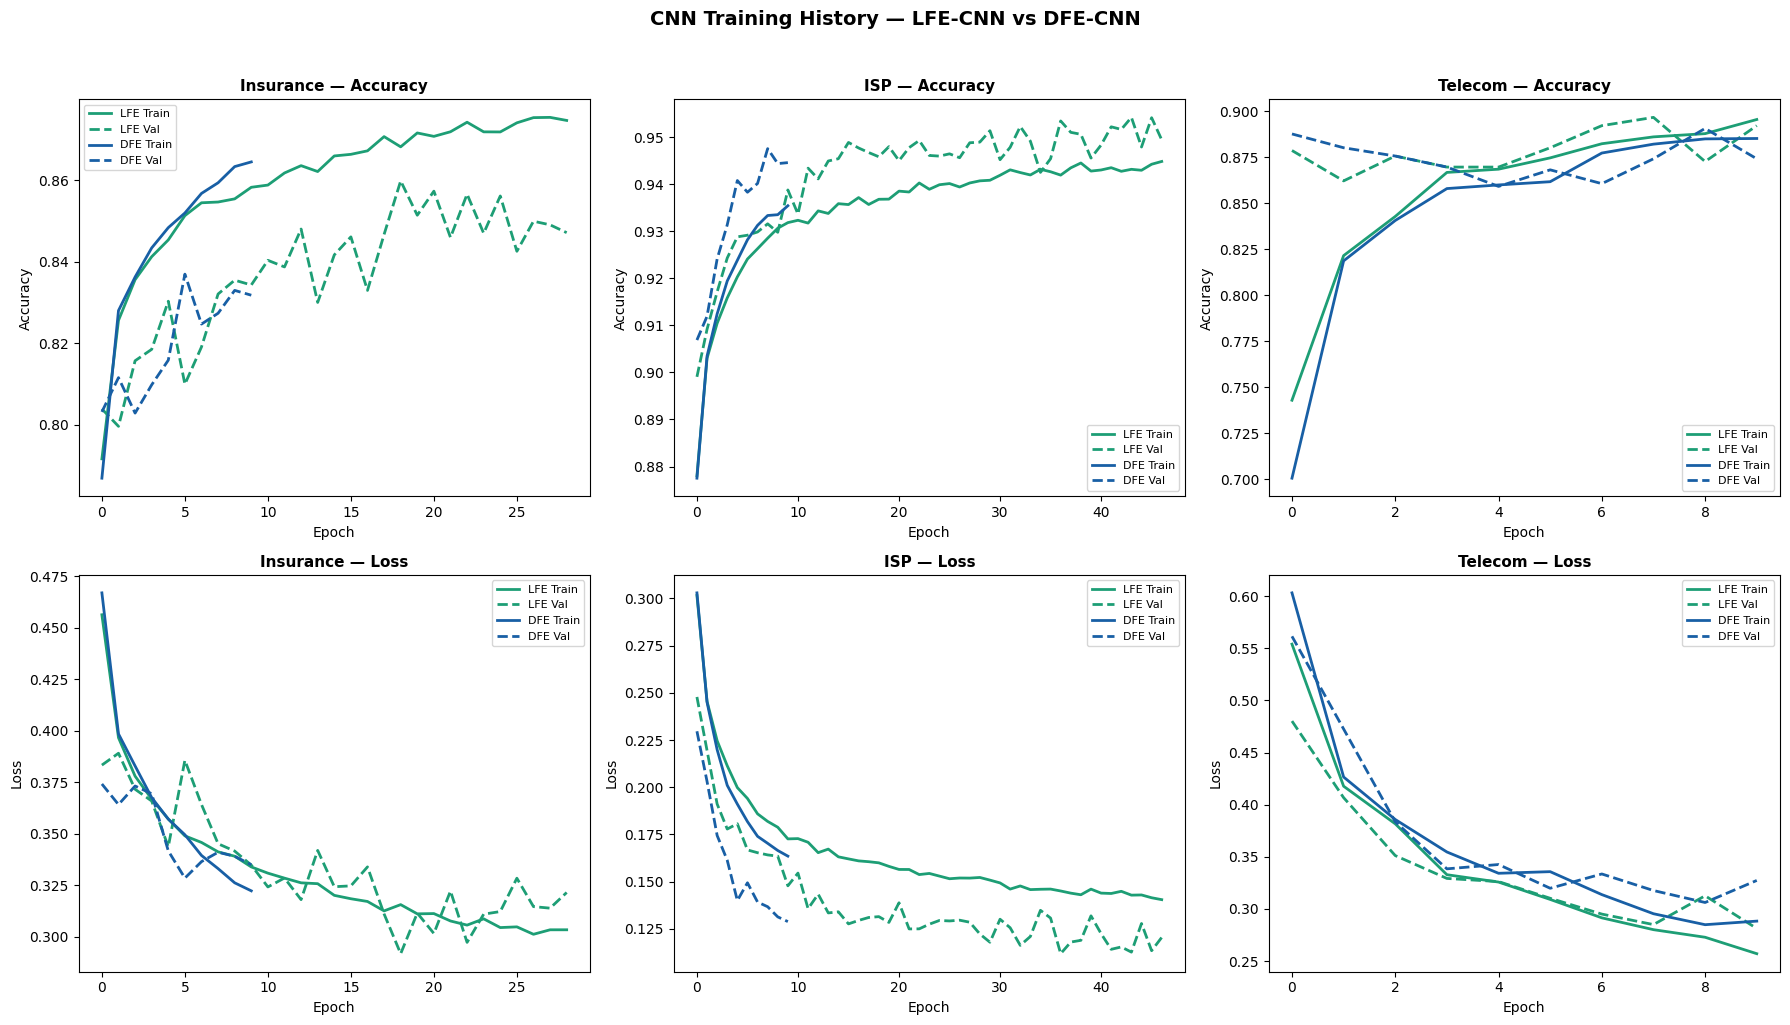

✓ Saved training history plots


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, name in enumerate(datasets):
    # Accuracy
    axes[0, col].plot(lfe_history[name].history['accuracy'],
                      label='LFE Train', color='#1D9E75', linewidth=2)
    axes[0, col].plot(lfe_history[name].history['val_accuracy'],
                      label='LFE Val',   color='#1D9E75',
                      linewidth=2, linestyle='--')
    axes[0, col].plot(dfe_history[name].history['accuracy'],
                      label='DFE Train', color='#185FA5', linewidth=2)
    axes[0, col].plot(dfe_history[name].history['val_accuracy'],
                      label='DFE Val',   color='#185FA5',
                      linewidth=2, linestyle='--')
    axes[0, col].set_title(f'{name} — Accuracy',
                            fontweight='bold', fontsize=11)
    axes[0, col].set_xlabel('Epoch')
    axes[0, col].set_ylabel('Accuracy')
    axes[0, col].legend(fontsize=8)

    # Loss
    axes[1, col].plot(lfe_history[name].history['loss'],
                      label='LFE Train', color='#1D9E75', linewidth=2)
    axes[1, col].plot(lfe_history[name].history['val_loss'],
                      label='LFE Val',   color='#1D9E75',
                      linewidth=2, linestyle='--')
    axes[1, col].plot(dfe_history[name].history['loss'],
                      label='DFE Train', color='#185FA5', linewidth=2)
    axes[1, col].plot(dfe_history[name].history['val_loss'],
                      label='DFE Val',   color='#185FA5',
                      linewidth=2, linestyle='--')
    axes[1, col].set_title(f'{name} — Loss',
                            fontweight='bold', fontsize=11)
    axes[1, col].set_xlabel('Epoch')
    axes[1, col].set_ylabel('Loss')
    axes[1, col].legend(fontsize=8)

plt.suptitle('CNN Training History — LFE-CNN vs DFE-CNN',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS + 'cnn_training_history.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved training history plots")

**Save CNN models and results**

In [10]:
# Save results
cnn_results_df.to_csv(RESULTS + 'cnn_results.csv', index=False)
print("✓ CNN results saved → results/cnn_results.csv")

# Save models
lfe_models_path = PROC + 'lfe_models.pkl'
dfe_models_path = PROC + 'dfe_models.pkl'

with open(lfe_models_path, 'wb') as f:
    pickle.dump(lfe_models, f)
with open(dfe_models_path, 'wb') as f:
    pickle.dump(dfe_models, f)

print("✓ LFE models saved → data/processed/lfe_models.pkl")
print("✓ DFE models saved → data/processed/dfe_models.pkl")
print("\n✓ Next step: run 05_ensemble notebook")

✓ CNN results saved → results/cnn_results.csv
✓ LFE models saved → data/processed/lfe_models.pkl
✓ DFE models saved → data/processed/dfe_models.pkl

✓ Next step: run 05_ensemble notebook
